# Step 1: Data Loading & Understanding

In this step:
- Load CSV, JSON, and SQL datasets
- Display sample data
- Check structure and missing values

## IMPORT LIBRARIES

In [1]:
# 1. IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import sqlite3

# Visualization (optional bonus)
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn preprocessing tools
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# For outlier detection
from scipy import stats

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## LOAD DATASETS

#### 1. LOAD JSON FILE (TRIPS DATA)

In [2]:
# JSON file contains ride trip details

trips = pd.read_json(r"C:\Users\tanaa\Downloads\trips.json")

# Display first 5 rows
print("Trips Data (JSON):")
display(trips.head())

Trips Data (JSON):


,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,1
2,T00003,R0045,Zone_8,4.70,31.03,46.39,Cash,2024-01-14,1
3,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,0
4,T00005,R0003,Zone_5,7.28,67.59,72.74,UPI,2023-03-15,1


#### 2. LOAD CSV FILE (RIDERS DATA)

In [3]:
# CSV file contains rider information

riders = pd.read_csv(r"C:\Users\tanaa\Downloads\riders - riders.csv.csv")

# Display first 5 rows
print("Riders Data (CSV):")
display(riders.head())

Riders Data (CSV):


,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating
0,R0001,Aarav Das,23,Male,Pune,2020-06-29,56,0,3.76
1,R0002,Ishaan Nair,39,Female,Mumbai,2019-11-23,70,5,4.12
2,R0003,Kavya Reddy,34,Male,Pune,2023-05-04,45,9,3.76
3,R0004,Aarav Nair,19,Other,Kolkata,2019-07-28,464,5,3.19
4,R0005,Diya Reddy,27,Male,Ahmedabad,2021-05-31,294,30,3.53


In [4]:
import mysql.connector

#### 3. LOAD SQL FILE (CITY ZONES DATA)

In [69]:
# SQL file contains zone-level information
# Step 1: Create database from SQL file

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="0212",
    database="city_zone"
)

# Load SQL table
city_zones = pd.read_sql("SELECT * FROM city_zones", conn)

# Output
print("City Zones Data:")
city_zones.head()

City Zones Data:


,zone_name,population_density,traffic_index,avg_speed_kmph,zone_type
0,Zone_1,4921,2.43,30.9,Residential
1,Zone_10,2440,1.54,35.4,Industrial
2,Zone_2,6371,0.91,58.4,Residential
3,Zone_3,12971,2.11,38.0,Business
4,Zone_4,4038,2.46,48.2,Business


## DATA MERGING (FINAL)

In [79]:
# Clean column names (remove spaces)
df_merge1['zone_name'] = df_merge1['zone_name'].str.strip()
city_zones['zone_name'] = city_zones['zone_name'].str.strip()

# Re-merge
df_final = pd.merge(df_merge1, city_zones, on='zone_name', how='left')

print("Merge fixed successfully")
df_final.head()

Merge fixed successfully


,trip_id,rider_id,zone_name,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag,name,...,gender,city,signup_date,total_rides,cancelled_rides,avg_rating,population_density,traffic_index,avg_speed_kmph,zone_type
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0,Aadhya Iyer,...,Other,Ahmedabad,2020-11-21,489,6,3.36,2440,1.54,35.4,Industrial
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,1,Diya Gupta,...,Male,Kolkata,2021-05-27,328,1,3.70,11037,1.83,56.1,Mixed
2,T00003,R0045,Zone_8,4.70,31.03,46.39,Cash,2024-01-14,1,Saanvi Iyer,...,Other,Ahmedabad,2023-07-12,100,16,4.88,4516,1.93,31.0,Business
3,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,0,Saanvi Reddy,...,Other,Surat,2022-09-21,308,6,3.91,6371,0.91,58.4,Residential
4,T00005,R0003,Zone_5,7.28,67.59,72.74,UPI,2023-03-15,1,Kavya Reddy,...,Male,Pune,2023-05-04,45,9,3.76,2590,1.31,43.9,Business


#### BASIC INFO

In [80]:
# info() → column info + data types

df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   trip_id             2000 non-null   object 
 1   rider_id            2000 non-null   object 
 2   zone_name           2000 non-null   object 
 3   distance_km         2000 non-null   float64
 4   duration_min        2000 non-null   float64
 5   fare_amount         2000 non-null   float64
 6   payment_mode        2000 non-null   object 
 7   ride_date           2000 non-null   object 
 8   surge_flag          2000 non-null   int64  
 9   name                2000 non-null   object 
 10  age                 2000 non-null   int64  
 11  gender              2000 non-null   object 
 12  city                2000 non-null   object 
 13  signup_date         2000 non-null   object 
 14  total_rides         2000 non-null   int64  
 15  cancelled_rides     2000 non-null   int64  
 16  avg_ra

In [81]:
df = df_final.copy()

# Step:2. Data Cleaning

In this step:
- Handle missing values
- Fix date formats
- Remove invalid entries

#### CHECK MISSING VALUES BEFORE

In [82]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 trip_id               0
rider_id              0
zone_name             0
distance_km           0
duration_min          0
fare_amount           0
payment_mode          0
ride_date             0
surge_flag            0
name                  0
age                   0
gender                0
city                  0
signup_date           0
total_rides           0
cancelled_rides       0
avg_rating            0
population_density    0
traffic_index         0
avg_speed_kmph        0
zone_type             0
dtype: int64


#### HANDLE NUMERICAL MISSING VALUES (MEAN)

In [83]:
num_cols = df.select_dtypes(include=np.number).columns
num_imputer = SimpleImputer(strategy='mean')# Select numerical columns
num_cols = df.select_dtypes(include=np.number).columns

# Mean imputation replaces missing values with average value of column
num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

print("\nNumerical columns handled using MEAN imputation")
df[num_cols] = num_imputer.fit_transform(df[num_cols])


Numerical columns handled using MEAN imputation


#### HANDLE CATEGORICAL MISSING VALUES (MODE)

In [84]:
# Select categorical (text) columns
cat_cols = df.select_dtypes(include='object').columns

# Mode imputation replaces missing values with most frequent value
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("Categorical columns handled using MODE imputation")

Categorical columns handled using MODE imputation


#### KNN IMPUTATION (ADVANCED METHOD)

In [85]:
# KNN uses nearest neighbor values to fill missing data
knn_cols = ['distance_km', 'duration_min', 'fare_amount']

# Apply only if columns exist
knn_cols = [col for col in knn_cols if col in df.columns]

if knn_cols:
    knn_imputer = KNNImputer(n_neighbors=5)
    df[knn_cols] = knn_imputer.fit_transform(df[knn_cols])

    print(" Missing values refined using KNN Imputer")

 Missing values refined using KNN Imputer


#### CHECK MISSING VALUES (AFTER)

In [86]:
print("\nMissing Values AFTER Cleaning:\n")
print(df.isnull().sum())


Missing Values AFTER Cleaning:

trip_id               0
rider_id              0
zone_name             0
distance_km           0
duration_min          0
fare_amount           0
payment_mode          0
ride_date             0
surge_flag            0
name                  0
age                   0
gender                0
city                  0
signup_date           0
total_rides           0
cancelled_rides       0
avg_rating            0
population_density    0
traffic_index         0
avg_speed_kmph        0
zone_type             0
dtype: int64


## NOTE 

 NOTE:
 If no missing values were present in the dataset,
 the imputation methods (Mean, Mode, KNN) do not change the data.
 They are applied here to demonstrate data preprocessing techniques.

#### FIX DATE FORMAT

In [87]:
# Convert ride_date into datetime format
df['ride_date'] = pd.to_datetime(df['ride_date'], errors='coerce')

print("\nDate column converted to datetime format")


Date column converted to datetime format


#### REMOVE INVALID DATA

In [88]:
# Remove negative fare values
df = df[df['fare_amount'] >= 0]

# Remove zero or negative distance values
df = df[df['distance_km'] > 0]

print("Invalid data removed (negative fare & zero distance)")

Invalid data removed (negative fare & zero distance)


#### FINAL DATA SHAPE

In [89]:
print("\nFinal dataset shape after cleaning:", df.shape)
print("\nData Cleaning Completed Successfully")


Final dataset shape after cleaning: (2000, 21)

Data Cleaning Completed Successfully


#### Explanation:

- Missing values were checked before handling.
- Numerical columns were filled using mean imputation.
- Categorical columns were handled using mode (most frequent) imputation.
- KNN Imputer was applied as an advanced method to improve data quality.
- Missing values were checked again to confirm they are handled.
- Date column was converted into proper datetime format.
- Invalid records like negative fare and zero distance were removed.

This ensures the dataset is clean and ready for further processing.

# Step:3. Outlier Handling

We detect and remove extreme values using:
- Z-score method
- IQR method
- Winsorization
    
Outliers can negatively affect model performance, so they are removed or capped.

#### CHECK DATA BEFORE OUTLIER REMOVAL

In [90]:
print("Data Shape BEFORE Outlier Handling:", df.shape)

Data Shape BEFORE Outlier Handling: (2000, 21)


#### 1. Z-SCORE METHOD

In [91]:
# Z-score identifies how far a value is from mean (in terms of standard deviation)
# Values with Z-score > 3 are considered outliers

z = np.abs(stats.zscore(df[['fare_amount', 'distance_km']]))

# Keep only rows where Z-score < 3
df = df[(z < 3).all(axis=1)]

print("Outliers removed using Z-score method")

Outliers removed using Z-score method


#### 2. IQR METHOD (INTERQUARTILE RANGE)

In [92]:
# IQR = Q3 - Q1
# Values outside (Q1 - 1.5*IQR, Q3 + 1.5*IQR) are considered outliers
# IQR detects outliers based on quartiles (Q1 and Q3)

Q1 = df['duration_min'].quantile(0.25)
Q3 = df['duration_min'].quantile(0.75)
IQR = Q3 - Q1

# Keep values within acceptable range
df = df[(df['duration_min'] >= Q1 - 1.5 * IQR) &
        (df['duration_min'] <= Q3 + 1.5 * IQR)]

print("Outliers handled using IQR method")

Outliers handled using IQR method


#### 3. WINSORIZATION (CAPPING EXTREME VALUES)

In [93]:
# Instead of removing rows, we limit extreme values
# Values below 1% and above 99% are capped
# Instead of removing, we cap extreme values to reduce impact

lower_limit = df['fare_amount'].quantile(0.01)
upper_limit = df['fare_amount'].quantile(0.99)

df['fare_amount'] = np.clip(df['fare_amount'], lower_limit, upper_limit)

print("Extreme values capped using Winsorization")

Extreme values capped using Winsorization


#### FINAL DATA SHAPE


In [94]:
print("\nData Shape AFTER Outlier Handling:", df.shape)
print("\nOutlier Handling Completed Successfully")


Data Shape AFTER Outlier Handling: (1971, 21)

Outlier Handling Completed Successfully


#### Explanation:

- First, the dataset size was checked before removing outliers.
- Z-score method was used to remove extreme values based on standard deviation.
- IQR method was applied to detect and remove outliers based on quartile range.
- Winsorization was used to cap extreme values instead of removing them completely.
- Finally, dataset size was checked again to confirm the changes.

These steps help in improving data quality and reducing the impact of extreme values.

# Step 4: Data Transformation

In this step, we:
- Extract useful features from datetime column
- Encode categorical variables into numerical form
- Transform skewed numerical data for better distribution

These transformations help improve model performance.

#### CHECK DATA BEFORE TRANSFORMATION

In [95]:
print("Data Sample BEFORE Transformation:\n")
df.head()

Data Sample BEFORE Transformation:



,trip_id,rider_id,zone_name,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag,name,...,gender,city,signup_date,total_rides,cancelled_rides,avg_rating,population_density,traffic_index,avg_speed_kmph,zone_type
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0.0,Aadhya Iyer,...,Other,Ahmedabad,2020-11-21,489.0,6.0,3.36,2440.0,1.54,35.4,Industrial
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,1.0,Diya Gupta,...,Male,Kolkata,2021-05-27,328.0,1.0,3.70,11037.0,1.83,56.1,Mixed
2,T00003,R0045,Zone_8,4.70,31.03,46.39,Cash,2024-01-14,1.0,Saanvi Iyer,...,Other,Ahmedabad,2023-07-12,100.0,16.0,4.88,4516.0,1.93,31.0,Business
3,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,0.0,Saanvi Reddy,...,Other,Surat,2022-09-21,308.0,6.0,3.91,6371.0,0.91,58.4,Residential
4,T00005,R0003,Zone_5,7.28,67.59,72.74,UPI,2023-03-15,1.0,Kavya Reddy,...,Male,Pune,2023-05-04,45.0,9.0,3.76,2590.0,1.31,43.9,Business


#### 1. EXTRACT DATETIME FEATURES

In [96]:
# Extract hour → helps identify peak time
df['hour'] = df['ride_date'].dt.hour

# Extract day of week → weekday/weekend analysis
df['day_of_week'] = df['ride_date'].dt.dayofweek

# Extract month → seasonal trends
df['month'] = df['ride_date'].dt.month

print("\nDatetime features extracted (hour, day_of_week, month)")


Datetime features extracted (hour, day_of_week, month)


#### 2. ENCODING CATEGORICAL VARIABLES

In [103]:
# -------------------------------
# LABEL ENCODING (CATEGORICAL → NUMERIC)
# -------------------------------

# Convert gender into numeric values
le = LabelEncoder()

if 'gender' in df.columns:
    df['gender'] = le.fit_transform(df['gender'])
    print("Gender column encoded using Label Encoding")


# -------------------------------
# ORDINAL ENCODING (ORDERED DATA)
# -------------------------------

# Traffic level example (if exists)
# Low < Medium < High

traffic_map = {'Low': 1, 'Medium': 2, 'High': 3}

if 'traffic_index' in df.columns:
    df['traffic_index'] = df['traffic_index'].map(traffic_map)
    print("Traffic level encoded using Ordinal Encoding")


# -------------------------------
# TRANSFORM SKEWED DATA
# -------------------------------

# Apply transformations to reduce skewness

df['fare_amount'] = np.log1p(df['fare_amount'])   # log transform
df['distance_km'] = np.log1p(df['distance_km'])   # log transform
df['duration_min'] = np.sqrt(df['duration_min'])  # square root transform

print("Skewed data transformed (log & sqrt applied)")


Gender column encoded using Label Encoding
Traffic level encoded using Ordinal Encoding
Skewed data transformed (log & sqrt applied)


In [104]:
# ORDINAL ENCODING (TRAFFIC LEVEL)

# Low < Medium < High

# Traffic level is an ordered category:
traffic_map = {'Low': 1, 'Medium': 2, 'High': 3}

# Apply mapping on correct dataframe (df)
df['traffic_index'] = df['traffic_index'].map(traffic_map)

print("Traffic level encoded using Ordinal Encoding")

Traffic level encoded using Ordinal Encoding


## Binning

In [105]:
# pd.cut() → convert numeric → categories (binning)

df['ride_frequency'] = pd.cut(
    df['total_rides'],
    bins=[0, 50, 150, 1000],
    labels=['Low', 'Medium', 'High']
)

#### CHECK DATA AFTER TRANSFORMATION

In [106]:
print("\nData Shape AFTER TRANSFORMATION:", df.shape)
print("\nData Transformation Completed Successfully")
print("\nData Sample AFTER Transformation:\n")
df.head()



Data Shape AFTER TRANSFORMATION: (1971, 25)

Data Transformation Completed Successfully

Data Sample AFTER Transformation:



,trip_id,rider_id,zone_name,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag,name,...,cancelled_rides,avg_rating,population_density,traffic_index,avg_speed_kmph,zone_type,hour,day_of_week,month,ride_frequency
0,T00001,R0037,Zone_10,0.818656,1.714293,1.005704,Cash,2023-11-13,0.0,Aadhya Iyer,...,6.0,3.36,2440.0,NaN,35.4,Industrial,0,0,11,High
1,T00002,R0104,Zone_9,0.666902,1.562845,0.937235,Cash,2023-07-28,1.0,Diya Gupta,...,1.0,3.70,11037.0,NaN,56.1,Mixed,0,4,7,High
2,T00003,R0045,Zone_8,0.697203,1.536288,0.948065,Cash,2024-01-14,1.0,Saanvi Iyer,...,16.0,4.88,4516.0,NaN,31.0,Business,0,6,1,Medium
3,T00004,R0089,Zone_2,0.810873,1.666466,1.057893,Cash,2023-12-13,0.0,Saanvi Reddy,...,6.0,3.91,6371.0,NaN,58.4,Residential,0,2,12,High
4,T00005,R0003,Zone_5,0.758868,1.693305,0.981258,UPI,2023-03-15,1.0,Kavya Reddy,...,9.0,3.76,2590.0,NaN,43.9,Business,0,2,3,Low


#### Explanation:

- Datetime features such as hour, day_of_week, and month were extracted from the date column.
- Label encoding was applied to convert categorical data (like gender) into numeric form.
- Ordinal encoding was used for ordered categories such as traffic level.
- Skewed numerical data was transformed using log and square root functions to normalize distribution.
- Data was checked before and after transformation to verify changes.

This step prepares the data for better analysis and machine learning performance.

# STEP 5: FEATURE SCALING

In this step, numerical features are scaled to bring them to a common range.

### Why Feature Scaling?
- Different features have different ranges (e.g., fare vs distance)
- Machine learning models perform better when data is normalized
- Prevents bias towards features with larger values

### Method Used:
- **StandardScaler**
  - Converts data so that:
    - Mean = 0
    - Standard Deviation = 1

### Columns Scaled:
- fare_amount
- distance_km
- duration_min

### Outcome:
- All numerical features are now on the same scale
- Data is ready for modeling and analysis

#### CHECK DATA BEFORE SCALING

In [107]:
print("Data BEFORE Scaling (sample):\n")
df[['fare_amount', 'distance_km', 'duration_min']].head()

Data BEFORE Scaling (sample):



,fare_amount,distance_km,duration_min
0,1.005704,0.818656,1.714293
1,0.937235,0.666902,1.562845
2,0.948065,0.697203,1.536288
3,1.057893,0.810873,1.666466
4,0.981258,0.758868,1.693305


### APPLY STANDARD SCALING

In [108]:
# StandardScaler converts data into standard format:
# Mean = 0 and Standard Deviation = 1

scaler = StandardScaler()

# Select numerical columns for scaling
scale_cols = ['fare_amount', 'distance_km', 'duration_min']

# Ensure columns exist (safe check)
scale_cols = [col for col in scale_cols if col in df.columns]

# Apply scaling
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("\nFeature Scaling applied using StandardScaler")


Feature Scaling applied using StandardScaler


In [109]:
# MinMaxScaler() → scales between 0–1

scaler = MinMaxScaler()

cols = ['distance_km', 'duration_min', 'fare_amount']

df[cols] = scaler.fit_transform(df[cols])
print("\nFeature Scaling applies using MinMaxScaler")


Feature Scaling applies using MinMaxScaler


#### CHECK DATA AFTER SCALING

In [110]:
print("\nData AFTER Scaling (sample):\n")
print("\nFeature Scaling Completed Successfully")
df[scale_cols].head()


Data AFTER Scaling (sample):


Feature Scaling Completed Successfully


,fare_amount,distance_km,duration_min
0,0.848333,0.930765,0.843484
1,0.691157,0.754037,0.701822
2,0.716019,0.789325,0.676981
3,0.968136,0.921702,0.798747
4,0.792215,0.861138,0.823852


### Explanation:

- Feature scaling was applied to numerical columns such as fare_amount, distance_km, and duration_min.
- StandardScaler was used to standardize the data so that each feature has a mean of 0 and standard deviation of 1.
- This helps in improving the performance of machine learning models.
- Data was displayed before and after scaling to verify the transformation.

This step ensures that all features are on the same scale and prevents bias due to different value ranges.

# Step 6: Feature Construction

In this step:
- Create new meaningful features from existing data
- Improve dataset for machine learning
- Features are created based on given logic

### avg_ride_distance

In [111]:
# total distance / total trips

df['avg_ride_distance'] = df['distance_km'] / df['total_rides']

print("avg_ride_distance created")

avg_ride_distance created


### avg_ride_fare

In [112]:
# total fare / total rides

df['avg_ride_fare'] = df['fare_amount'] / df['total_rides']

print("avg_ride_fare created")

avg_ride_fare created


### is_peak_hour

In [113]:
# 1 if hour in [7-9, 18-21] else 0

df['is_peak_hour'] = df['hour'].apply(
    lambda x: 1 if (7 <= x <= 9 or 18 <= x <= 21) else 0
)

print("is_peak_hour created")

is_peak_hour created


### days_since_signup

In [114]:
# today - signup_date

df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')

today = pd.to_datetime('today')

df['days_since_signup'] = (today - df['signup_date']).dt.days

print("days_since_signup created")

days_since_signup created


### ride_cancellation_rate

In [115]:
# cancelled_rides / total_rides

df['ride_cancellation_rate'] = df['cancelled_rides'] / df['total_rides']

print("ride_cancellation_rate created")

ride_cancellation_rate created


### surge_flag

In [116]:
# 1 if fare/distance > threshold

df['fare_per_km'] = df['fare_amount'] / df['distance_km']

threshold = df['fare_per_km'].mean()

df['surge_flag_new'] = df['fare_per_km'].apply(
    lambda x: 1 if x > threshold else 0
)

print("surge_flag created")

surge_flag created


### CHECK DATA AFTER

In [123]:
print("\nFeature Construction Completed Successfully")
print("\nData AFTER Feature Construction:\n")
df[['avg_ride_distance', 'avg_ride_fare', 'is_peak_hour',
          'days_since_signup', 'ride_cancellation_rate', 'surge_flag_new']].head()



Feature Construction Completed Successfully

Data AFTER Feature Construction:



,avg_ride_distance,avg_ride_fare,is_peak_hour,days_since_signup,ride_cancellation_rate,surge_flag_new
0,0.001903,0.001735,0,1988,0.012270,0
1,0.002299,0.002107,0,1801,0.003049,0
2,0.007893,0.007160,0,1025,0.160000,0
3,0.002993,0.003143,0,1319,0.019481,1
4,0.019136,0.017605,0,1094,0.200000,0


### Explanation:

- avg_ride_distance was calculated using total distance divided by total rides.
- avg_ride_fare was calculated using total fare divided by total rides.
- is_peak_hour identifies whether a ride happened during peak hours.
- days_since_signup calculates how many days since the user registered.
- ride_cancellation_rate shows the ratio of cancelled rides.
- surge_flag identifies high fare rides based on fare per distance.

These features improve the dataset and help in better prediction and analysis.

# STEP 7: EXPORT FINAL DATASET

In this step:
- Save the final processed dataset
- Ensure data is ready for analysis or modeling
- Export file in CSV format

In [127]:
print("\nFinal Dataset Shape:", df.shape)
print("Final Dataset Preview:\n")
df.head()


Final Dataset Shape: (1971, 32)
Final Dataset Preview:



,trip_id,rider_id,zone_name,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag,name,...,day_of_week,month,ride_frequency,avg_ride_distance,avg_ride_fare,is_peak_hour,days_since_signup,ride_cancellation_rate,fare_per_km,surge_flag_new
0,T00001,R0037,Zone_10,0.930765,0.843484,0.848333,Cash,2023-11-13,0.0,Aadhya Iyer,...,0,11,High,0.001903,0.001735,0,1988,0.012270,0.911436,0
1,T00002,R0104,Zone_9,0.754037,0.701822,0.691157,Cash,2023-07-28,1.0,Diya Gupta,...,4,7,High,0.002299,0.002107,0,1801,0.003049,0.916609,0
2,T00003,R0045,Zone_8,0.789325,0.676981,0.716019,Cash,2024-01-14,1.0,Saanvi Iyer,...,6,1,Medium,0.007893,0.007160,0,1025,0.160000,0.907128,0
3,T00004,R0089,Zone_2,0.921702,0.798747,0.968136,Cash,2023-12-13,0.0,Saanvi Reddy,...,2,12,High,0.002993,0.003143,0,1319,0.019481,1.050379,1
4,T00005,R0003,Zone_5,0.861138,0.823852,0.792215,UPI,2023-03-15,1.0,Kavya Reddy,...,2,3,Low,0.019136,0.017605,0,1094,0.200000,0.919962,0


### SAVE DATASET TO CSV

In [132]:
df.to_csv("C:/Users/tanaa/Downloads/final_rides_dataset.csv", index=False)

print("File saved successfully")

File saved successfully


# STEP: 8

In [134]:
# ================================
# SAVE DATASET AS HTML FILE
# ================================

output_path = "C:/Users/tanaa/Downloads/final_rides_dataset.html"

# Convert dataframe to HTML
df.to_html(output_path, index=False)

print("Dataset saved successfully in HTML format")

Dataset saved successfully in HTML format


### Explanation:

- The final dataset was converted into HTML format using to_html().
- This allows data to be viewed in a browser as a table.
- Styling was added to improve readability and presentation.

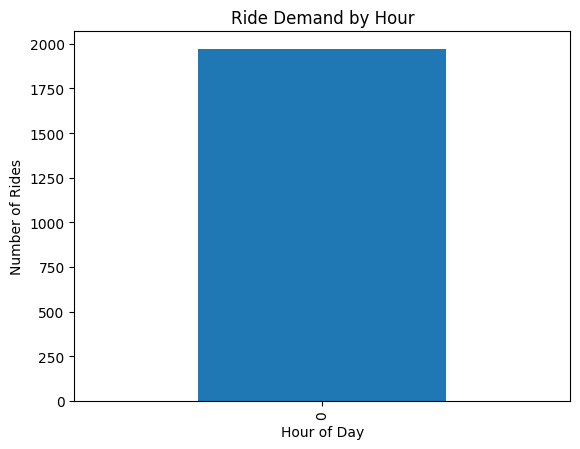

Ride demand by hour visualized


In [138]:
# ================================
# RIDE DEMAND BY HOUR
# ================================

import matplotlib.pyplot as plt

# Count number of rides per hour
ride_demand = df['hour'].value_counts().sort_index()

# Plot graph
plt.figure()
ride_demand.plot(kind='bar')

plt.title("Ride Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rides")

plt.show()

print("Ride demand by hour visualized")

- This graph shows how ride demand changes throughout the day.
- Helps identify peak hours when demand is high.
- Useful for pricing and driver allocation.

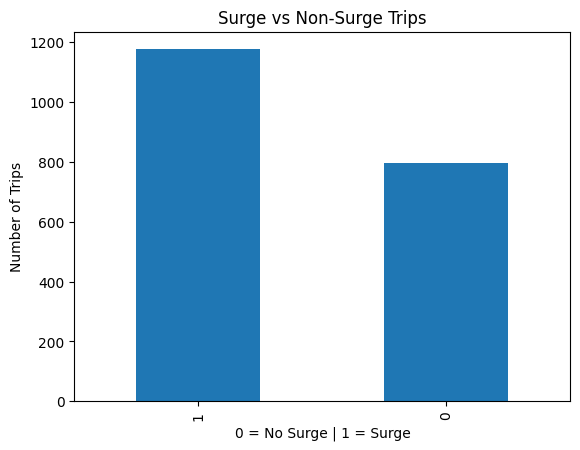

Surge vs Non-Surge visualization created


In [140]:
# ================================
# SURGE vs NON-SURGE TRIPS
# ================================

# Check which surge column exists
if 'surge_flag_new' in df.columns:
    surge_col = 'surge_flag_new'
else:
    surge_col = 'surge_flag'

# Count surge vs non-surge
surge_counts = df[surge_col].value_counts()

# Plot graph
plt.figure()
surge_counts.plot(kind='bar')

plt.title("Surge vs Non-Surge Trips")
plt.xlabel("0 = No Surge | 1 = Surge")
plt.ylabel("Number of Trips")

plt.show()

print("Surge vs Non-Surge visualization created")

- This graph compares surge and non-surge trips.
- Helps understand how often surge pricing is applied.
- Useful for pricing strategy analysis.